<a href="https://colab.research.google.com/github/amirshokri17/Photogrammetry_EGMS/blob/main/photogrammetry_ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install pyjwt requests

In [ ]:
import json
import time
import requests
import jwt

def get_access_token():

    service_key = json.load(open("/content/token.jwt", "rb"))

    private_key = service_key["private_key"].encode("utf-8")

    claim_set = {
        "iss": service_key["client_id"],
        "sub": service_key["user_id"],
        "aud": service_key["token_uri"],
        "iat": int(time.time()),
        "exp": int(time.time() + 3600),
    }

    grant = jwt.encode(
        claim_set,
        private_key,
        algorithm="RS256"
    )

    result = requests.post(
        service_key["token_uri"],
        headers={
            "Accept": "application/json",
            "Content-Type": "application/x-www-form-urlencoded"
        },
        data={
            "grant_type": "urn:ietf:params:oauth:grant-type:jwt-bearer",
            "assertion": grant
        }
    )

    result.raise_for_status()

    return result.json()["access_token"]


access_token = get_access_token()

headers = {
    "Authorization": f"Bearer {access_token}",
    "Accept": "application/json"
}

print("Authentication successful")

In [4]:
bbox = [
    [21.92, 39.57],   # southwest: lon, lat
    [22.34, 39.86]    # northeast: lon, lat
]

api_endpoint = "https://egms.land.copernicus.eu/insar-api/archive"

In [5]:
query = {
    "id": None,
    "bbox": bbox,
    "levels": ["L3"],
    "releases": ["2020-2024"],
    "productType": "ORTHO-UP"
}

r = requests.post(
    f"{api_endpoint}/search",
    headers=headers,
    data=json.dumps(query)
)

print("HTTP status:", r.status_code)

result_vertical = r.json()

print("Hits:", len(result_vertical.get("hits", [])))

for hit in result_vertical.get("hits", []):
    print(
        hit["filename"],
        "|",
        round(hit["filesize"] / 1e6, 1),
        "MB"
    )

HTTP status: 200
Hits: 1
EGMS_L3_E53N19_100km_U_2020_2024_1.zip | 93.0 MB


In [6]:
from pathlib import Path
import subprocess

folder = Path("/content/EGMS_Greece")
folder.mkdir(exist_ok=True)

hit = result_vertical["hits"][0]

filename = hit["filename"]

download_url = (
    f"{api_endpoint}/download/"
    f"{filename}?id={result_vertical['id']}"
)

output_file = folder / filename

print("Downloading:", filename)

subprocess.run(
    ["wget", "-O", str(output_file), download_url],
    check=True
)

print("Saved:", output_file)
print("Size:", round(output_file.stat().st_size / 1e6, 1), "MB")

Downloading: EGMS_L3_E53N19_100km_U_2020_2024_1.zip
Saved: /content/EGMS_Greece/EGMS_L3_E53N19_100km_U_2020_2024_1.zip
Size: 93.0 MB


In [7]:
query_east = {
    "id": None,
    "bbox": bbox,
    "levels": ["L3"],
    "releases": ["2020-2024"],
    "productType": "ORTHO-EAST"
}

r = requests.post(
    f"{api_endpoint}/search",
    headers=headers,
    data=json.dumps(query_east)
)

print("HTTP status:", r.status_code)

result_east = r.json()

print("Hits:", len(result_east.get("hits", [])))

for hit in result_east.get("hits", []):
    print(
        hit["filename"],
        "|",
        round(hit["filesize"] / 1e6, 1),
        "MB"
    )

HTTP status: 200
Hits: 1
EGMS_L3_E53N19_100km_E_2020_2024_1.zip | 97.5 MB


In [8]:
hit = result_east["hits"][0]

filename = hit["filename"]

download_url = (
    f"{api_endpoint}/download/"
    f"{filename}?id={result_east['id']}"
)

output_file = folder / filename

print("Downloading:", filename)

subprocess.run(
    ["wget", "-O", str(output_file), download_url],
    check=True
)

print("Saved:", output_file)
print("Size:", round(output_file.stat().st_size / 1e6, 1), "MB")

Downloading: EGMS_L3_E53N19_100km_E_2020_2024_1.zip
Saved: /content/EGMS_Greece/EGMS_L3_E53N19_100km_E_2020_2024_1.zip
Size: 97.5 MB


In [9]:
import zipfile
from pathlib import Path

base = Path("/content/EGMS_Greece")

vertical_zip = base / "EGMS_L3_E53N19_100km_U_2020_2024_1.zip"
east_zip     = base / "EGMS_L3_E53N19_100km_E_2020_2024_1.zip"

vertical_dir = base / "vertical"
east_dir     = base / "eastwest"

vertical_dir.mkdir(exist_ok=True)
east_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(vertical_zip, "r") as z:
    z.extractall(vertical_dir)

with zipfile.ZipFile(east_zip, "r") as z:
    z.extractall(east_dir)

print("VERTICAL:")
for f in vertical_dir.iterdir():
    print(f.name)

print("\nEAST-WEST:")
for f in east_dir.iterdir():
    print(f.name)

VERTICAL:
EGMS_L3_E53N19_100km_U_2020_2024_1.xml
EGMS_L3_E53N19_100km_U_2020_2024_1.tiff
EGMS_L3_E53N19_100km_U_2020_2024_1.csv

EAST-WEST:
EGMS_L3_E53N19_100km_E_2020_2024_1.csv
EGMS_L3_E53N19_100km_E_2020_2024_1.xml
EGMS_L3_E53N19_100km_E_2020_2024_1.tiff


In [10]:
vertical_csvs = list(vertical_dir.glob("*.csv"))
east_csvs = list(east_dir.glob("*.csv"))

print("Vertical CSV:", vertical_csvs)
print("E-W CSV:", east_csvs)

Vertical CSV: [PosixPath('/content/EGMS_Greece/vertical/EGMS_L3_E53N19_100km_U_2020_2024_1.csv')]
E-W CSV: [PosixPath('/content/EGMS_Greece/eastwest/EGMS_L3_E53N19_100km_E_2020_2024_1.csv')]


In [11]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [12]:
!pip -q install pyproj pyarrow

In [13]:
from pyproj import Transformer

# AOI in lon/lat
lon_min, lat_min = 21.92, 39.57
lon_max, lat_max = 22.34, 39.86

transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3035",
    always_xy=True
)

# Transform all four corners
corners = [
    transformer.transform(lon_min, lat_min),
    transformer.transform(lon_min, lat_max),
    transformer.transform(lon_max, lat_min),
    transformer.transform(lon_max, lat_max)
]

xs = [p[0] for p in corners]
ys = [p[1] for p in corners]

xmin, xmax = min(xs), max(xs)
ymin, ymax = min(ys), max(ys)

print("EPSG:3035 bounds:")
print("Easting :", xmin, "to", xmax)
print("Northing:", ymin, "to", ymax)

EPSG:3035 bounds:
Easting : 5341745.6566237 to 5382089.554958239
Northing: 1911519.375457095 to 1949014.7281191896


In [15]:
import pandas as pd
from pathlib import Path

SAVE = Path("/content/drive/MyDrive/EGMS_Greece_Project")
SAVE.mkdir(exist_ok=True)

def clip_egms_csv(csv_path, output_path, chunksize=20000):

    selected = []

    for chunk in pd.read_csv(csv_path, chunksize=chunksize):

        mask = (
            chunk["easting"].between(xmin, xmax) &
            chunk["northing"].between(ymin, ymax)
        )

        clipped = chunk.loc[mask]

        if len(clipped) > 0:
            selected.append(clipped)

    result = pd.concat(selected, ignore_index=True)

    result.to_parquet(output_path, index=False)

    print("Saved:", output_path)
    print("AOI points:", len(result))
    print("Columns:", len(result.columns))

    return result

In [16]:
aoi_vertical = clip_egms_csv(
    vertical_csvs[0],
    SAVE / "greece_vertical_aoi.parquet"
)

aoi_eastwest = clip_egms_csv(
    east_csvs[0],
    SAVE / "greece_eastwest_aoi.parquet"
)

Saved: /content/drive/MyDrive/EGMS_Greece_Project/greece_vertical_aoi.parquet
AOI points: 54658
Columns: 317
Saved: /content/drive/MyDrive/EGMS_Greece_Project/greece_eastwest_aoi.parquet
AOI points: 54658
Columns: 317


In [17]:
print("Vertical:", aoi_vertical.shape)
print("E-W:", aoi_eastwest.shape)

print("\nVertical first columns:")
print(aoi_vertical.columns[:20].tolist())

Vertical: (54658, 317)
E-W: (54658, 317)

Vertical first columns:
['pid', 'easting', 'northing', 'height_ortho', 'rmse_ts', 'mean_velocity', 'mean_velocity_std', 'acceleration', 'acceleration_std', 'seasonality', 'seasonality_std', 'gnss_velocity_n', 'gnss_velocity_e', 'gnss_velocity_u', '20200102', '20200108', '20200114', '20200120', '20200126', '20200201']


In [19]:
aoi_vertical = pd.read_parquet(
    "/content/drive/MyDrive/EGMS_Greece_Project/greece_vertical_aoi.parquet"
)

aoi_eastwest = pd.read_parquet(
    "/content/drive/MyDrive/EGMS_Greece_Project/greece_eastwest_aoi.parquet"
)

In [20]:
import pandas as pd
import numpy as np

motion = aoi_vertical[
    ["pid", "easting", "northing",
     "rmse_ts", "mean_velocity", "mean_velocity_std"]
].merge(
    aoi_eastwest[
        ["pid", "easting", "northing",
         "rmse_ts", "mean_velocity", "mean_velocity_std"]
    ],
    on=["pid", "easting", "northing"],
    suffixes=("_vertical", "_eastwest")
)

print("Matched points:", len(motion))

quality_cols = [
    "rmse_ts_vertical",
    "rmse_ts_eastwest",
    "mean_velocity_std_vertical",
    "mean_velocity_std_eastwest"
]

print("\nQUALITY:")
print(
    motion[quality_cols]
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
    .T
)

print("\nVERTICAL VELOCITY:")
print(
    motion["mean_velocity_vertical"]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.25,
                           0.50, 0.75, 0.90, 0.95, 0.99])
)

print("\nE-W VELOCITY:")
print(
    motion["mean_velocity_eastwest"]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.25,
                           0.50, 0.75, 0.90, 0.95, 0.99])
)

Matched points: 54658

QUALITY:
                              count      mean        std  min  50%  75%  \
rmse_ts_vertical            54658.0  8.698778  13.704903  0.5  3.3  5.5   
rmse_ts_eastwest            54658.0  6.910030   4.029508  0.6  6.1  9.2   
mean_velocity_std_vertical  54658.0  0.539165   0.879859  0.0  0.2  0.3   
mean_velocity_std_eastwest  54658.0  0.421366   0.262964  0.0  0.4  0.6   

                              90%   95%   99%   max  
rmse_ts_vertical            23.73  47.6  60.3  73.0  
rmse_ts_eastwest            11.40  13.8  21.7  31.3  
mean_velocity_std_vertical   1.50   3.0   3.8   4.7  
mean_velocity_std_eastwest   0.70   0.9   1.4   2.0  

VERTICAL VELOCITY:
count    54658.000000
mean        -7.734127
std         19.961567
min        -95.300000
1%         -79.500000
5%         -62.715000
10%        -31.800000
25%         -7.500000
50%          1.000000
75%          2.500000
90%          3.700000
95%          4.300000
99%          5.400000
max          9.4

In [21]:
import numpy as np
import pandas as pd

# Very lenient QC: remove only extreme 1% tails
limits = {
    "rmse_v": motion["rmse_ts_vertical"].quantile(0.99),
    "rmse_e": motion["rmse_ts_eastwest"].quantile(0.99),
    "std_v":  motion["mean_velocity_std_vertical"].quantile(0.99),
    "std_e":  motion["mean_velocity_std_eastwest"].quantile(0.99)
}

motion_qc = motion[
    (motion["rmse_ts_vertical"] <= limits["rmse_v"]) &
    (motion["rmse_ts_eastwest"] <= limits["rmse_e"]) &
    (motion["mean_velocity_std_vertical"] <= limits["std_v"]) &
    (motion["mean_velocity_std_eastwest"] <= limits["std_e"])
].copy()

print("QC limits:", limits)
print("Before:", len(motion))
print("After :", len(motion_qc))
print("Retained:", round(100*len(motion_qc)/len(motion), 1), "%")

QC limits: {'rmse_v': np.float64(60.3), 'rmse_e': np.float64(21.7), 'std_v': np.float64(3.8), 'std_e': np.float64(1.4)}
Before: 54658
After : 53594
Retained: 98.1 %


In [22]:
motion_qc["vertical_class"] = np.select(
    [
        motion_qc["mean_velocity_vertical"] < -1,
        motion_qc["mean_velocity_vertical"].between(-1, 1),
        motion_qc["mean_velocity_vertical"] > 1
    ],
    ["Negative", "Stable", "Positive"]
)

print(motion_qc["vertical_class"].value_counts())

TypeError: Choicelist and default value do not have a common dtype: The DType <class 'numpy.dtypes._PyLongDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyLongDType'>)

In [23]:
motion_qc["vertical_class"] = np.select(
    [
        motion_qc["mean_velocity_vertical"] < -1,
        motion_qc["mean_velocity_vertical"].between(-1, 1),
        motion_qc["mean_velocity_vertical"] > 1
    ],
    [
        "Negative",
        "Stable",
        "Positive"
    ],
    default="Unknown"
)

print(motion_qc["vertical_class"].value_counts())

vertical_class
Positive    27218
Negative    17787
Stable       8589
Name: count, dtype: int64


In [24]:
date_cols = sorted([
    c for c in aoi_vertical.columns
    if len(str(c)) == 8 and str(c).isdigit()
])

dates = pd.to_datetime(date_cols, format="%Y%m%d")

event_date = pd.Timestamp("2021-03-03")

before_date = dates[dates < event_date].max()
after_date  = dates[dates > event_date].min()

before_col = before_date.strftime("%Y%m%d")
after_col  = after_date.strftime("%Y%m%d")

print("Number of acquisitions:", len(date_cols))
print("Before earthquake:", before_col)
print("After earthquake :", after_col)

Number of acquisitions: 303
Before earthquake: 20210225
After earthquake : 20210309


In [25]:
from sklearn.cluster import DBSCAN

def spatial_clusters(df, eps=150, min_samples=5):
    d = df.copy()

    d["spatial_cluster"] = DBSCAN(
        eps=eps,
        min_samples=min_samples
    ).fit_predict(
        d[["easting", "northing"]]
    )

    return d

negative = spatial_clusters(
    motion_qc[motion_qc["vertical_class"] == "Negative"]
)

positive = spatial_clusters(
    motion_qc[motion_qc["vertical_class"] == "Positive"]
)

stable = spatial_clusters(
    motion_qc[motion_qc["vertical_class"] == "Stable"]
)

In [26]:
print("NEGATIVE")
print(
    negative[negative["spatial_cluster"] != -1]
    ["spatial_cluster"]
    .value_counts()
    .head(10)
)

print("\nPOSITIVE")
print(
    positive[positive["spatial_cluster"] != -1]
    ["spatial_cluster"]
    .value_counts()
    .head(10)
)

print("\nSTABLE")
print(
    stable[stable["spatial_cluster"] != -1]
    ["spatial_cluster"]
    .value_counts()
    .head(10)
)

NEGATIVE
spatial_cluster
3      6272
0      4235
82      778
16      482
108     247
109     233
132     209
55      180
62      122
60      120
Name: count, dtype: int64

POSITIVE
spatial_cluster
178    5828
0      2831
26     2701
231    2246
41     1806
14     1007
129     674
184     460
232     357
205     349
Name: count, dtype: int64

STABLE
spatial_cluster
1      862
154    370
174    313
165    247
114    225
9      164
172    160
123    158
6      144
27     112
Name: count, dtype: int64


In [27]:
neg_zone = negative[negative["spatial_cluster"] == 3].copy()
pos_zone = positive[positive["spatial_cluster"] == 178].copy()
stable_zone = stable[stable["spatial_cluster"] == 1].copy()

print("Negative:", len(neg_zone))
print("Positive:", len(pos_zone))
print("Stable:", len(stable_zone))

Negative: 6272
Positive: 5828
Stable: 862


In [28]:
def rank_by_temporal_similarity(zone_df, source, n=20):

    # Get time series for points in this spatial zone
    d = source[source["pid"].isin(zone_df["pid"])].copy()
    d = d.set_index("pid")

    ts = d[date_cols].apply(pd.to_numeric, errors="coerce")

    # Normalize each point to its first valid observation
    ts_norm = ts.apply(
        lambda r: r - r.dropna().iloc[0]
        if r.notna().any() else r,
        axis=1
    )

    # Robust representative behaviour of the whole zone
    median_ts = ts_norm.median(axis=0)

    results = []

    for pid in ts_norm.index:

        s = ts_norm.loc[pid]

        # Similarity of temporal shape
        corr = s.corr(median_ts)

        # Difference from representative signal
        resid_rms = np.sqrt(
            np.nanmean((s - median_ts) ** 2)
        )

        rmse = zone_df.loc[
            zone_df["pid"] == pid,
            "rmse_ts_vertical"
        ].iloc[0]

        results.append({
            "pid": pid,
            "temporal_corr": corr,
            "residual_rms": resid_rms,
            "rmse_vertical": rmse
        })

    result = pd.DataFrame(results)

    # Smaller score = better representative
    result["score"] = (
        5 * (1 - result["temporal_corr"].fillna(0))
        + 0.2 * result["residual_rms"]
        + 0.1 * result["rmse_vertical"]
    )

    return result.sort_values("score").head(n), median_ts

In [29]:
neg_rank, neg_median = rank_by_temporal_similarity(
    neg_zone,
    aoi_vertical,
    n=20
)

pos_rank, pos_median = rank_by_temporal_similarity(
    pos_zone,
    aoi_vertical,
    n=20
)

display(neg_rank.head(10))
display(pos_rank.head(10))

,pid,temporal_corr,residual_rms,rmse_vertical,score
714,10NRKDyXxY,0.999964,0.800521,31.5,3.310287
4035,10NXymW754,0.999920,1.057400,31.5,3.361882
737,10NRKDyXy0,0.999919,1.047443,31.6,3.369895
779,10NROudn9y,0.999899,1.441972,31.1,3.398901
778,10NROudn9x,0.999897,1.645488,30.7,3.399614
3537,10NWv9CgMS,0.999929,1.255552,31.5,3.401465
3716,10NXIaWuKh,0.999955,1.359410,31.3,3.402109
3502,10NWqSXRAP,0.999906,1.326118,31.6,3.425692
601,10NRAqe3ZH,0.999692,1.997955,30.4,3.441130
1465,10NSbvHiHJ,0.999890,1.628401,31.3,3.456228


,pid,temporal_corr,residual_rms,rmse_vertical,score
559,10NbuZ6rDJ,0.995796,0.452979,2.6,0.371616
522,10NbpsRc1I,0.995898,0.449908,2.7,0.380489
564,10NbuZ6rDO,0.995150,0.585756,2.5,0.391402
876,10NcMh6KNX,0.994101,0.522284,2.6,0.393951
953,10NcRNlZZt,0.993280,0.579355,2.5,0.399472
936,10NcRNlZZb,0.995627,0.591252,2.6,0.400115
4404,10Ngfv1ITD,0.992743,0.578927,2.5,0.402069
667,10Nc3wRLbd,0.993002,0.593926,2.5,0.403775
836,10NcI0R5Bn,0.992642,0.594370,2.5,0.405666
4715,10NhQnfkPq,0.992811,0.655876,2.4,0.407121


In [30]:
import matplotlib.pyplot as plt

def plot_selected_timeseries(rank, source, title, n=10):

    pids = rank.head(n)["pid"].tolist()

    d = source[source["pid"].isin(pids)].copy()
    d = d.set_index("pid")

    ts = d[date_cols].apply(pd.to_numeric, errors="coerce")

    # Normalize to first observation
    ts = ts.apply(
        lambda r: r - r.dropna().iloc[0]
        if r.notna().any() else r,
        axis=1
    )

    plt.figure(figsize=(12,6))

    # individual selected points
    for pid in ts.index:
        plt.plot(
            dates,
            ts.loc[pid],
            linewidth=1,
            alpha=0.45
        )

    # median of selected points
    median_ts = ts.median(axis=0)

    plt.plot(
        dates,
        median_ts,
        linewidth=3,
        label="Median of selected points"
    )

    # earthquake
    plt.axvline(
        pd.Timestamp("2021-03-03"),
        linestyle="--",
        linewidth=2,
        label="3 March 2021 earthquake"
    )

    plt.xlabel("Date")
    plt.ylabel("Vertical displacement (mm)")
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

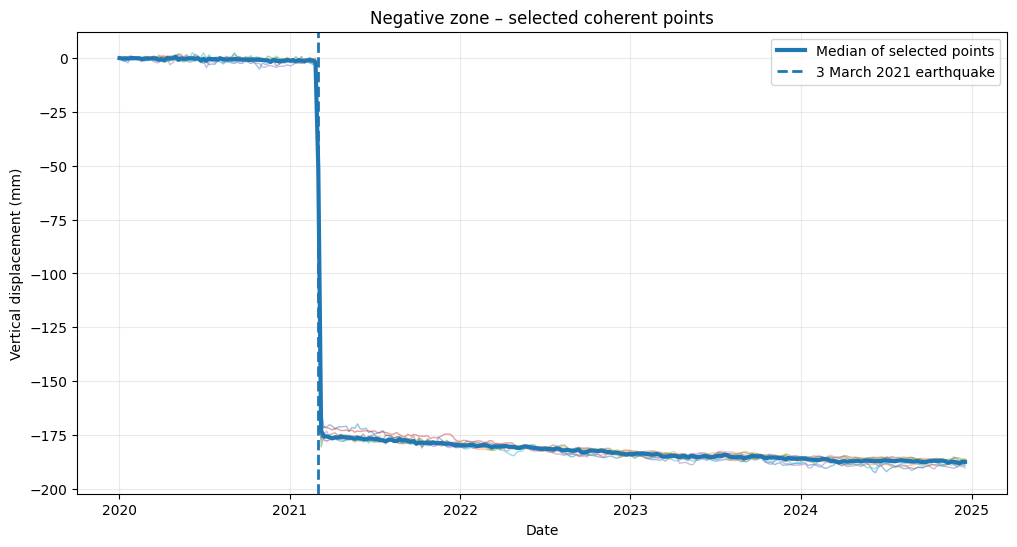

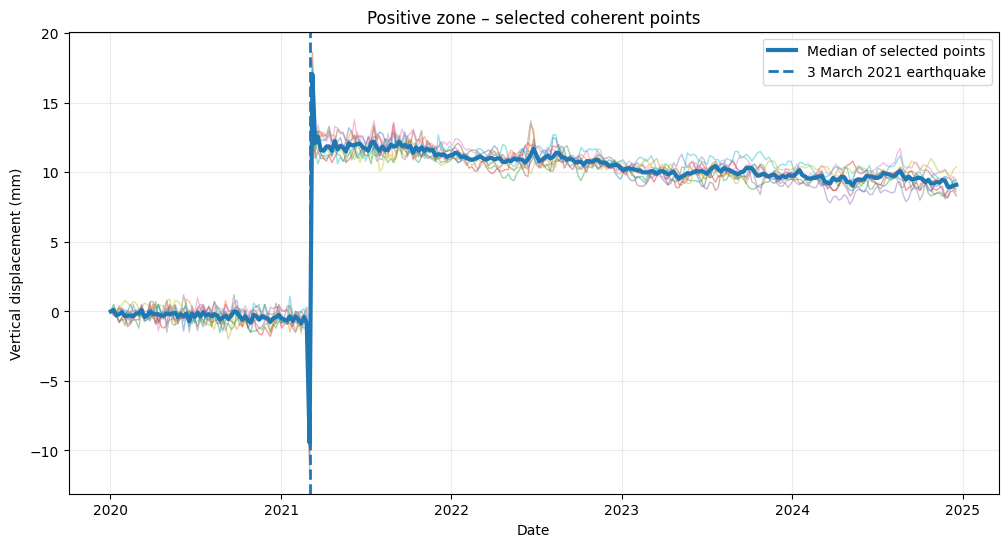

In [31]:
plot_selected_timeseries(
    neg_rank,
    aoi_vertical,
    "Negative zone – selected coherent points"
)

plot_selected_timeseries(
    pos_rank,
    aoi_vertical,
    "Positive zone – selected coherent points"
)

In [32]:
def earthquake_steps(rank, source, n=10):

    pids = rank.head(n)["pid"].tolist()

    d = source[source["pid"].isin(pids)].copy()
    d = d.set_index("pid")

    steps = (
        d[after_col] - d[before_col]
    )

    result = pd.DataFrame({
        "pid": steps.index,
        "earthquake_step_mm": steps.values
    })

    return result

print("NEGATIVE")
display(
    earthquake_steps(
        neg_rank,
        aoi_vertical
    )
)

print("POSITIVE")
display(
    earthquake_steps(
        pos_rank,
        aoi_vertical
    )
)

NEGATIVE


,pid,earthquake_step_mm
0,10NRAqe3ZH,-160.6
1,10NRKDyXxY,-171.0
2,10NRKDyXy0,-178.4
3,10NROudn9x,-172.7
4,10NROudn9y,-175.3
5,10NSbvHiHJ,-175.6
6,10NWqSXRAP,-172.4
7,10NWv9CgMS,-171.0
8,10NXIaWuKh,-168.8
9,10NXymW754,-171.0


POSITIVE


,pid,earthquake_step_mm
0,10NbpsRc1I,17.1
1,10NbuZ6rDJ,17.8
2,10NbuZ6rDO,16.8
3,10Nc3wRLbd,15.7
4,10NcI0R5Bn,17.1
5,10NcMh6KNX,18.3
6,10NcRNlZZb,18.2
7,10NcRNlZZt,17.8
8,10Ngfv1ITD,18.2
9,10NhQnfkPq,18.4


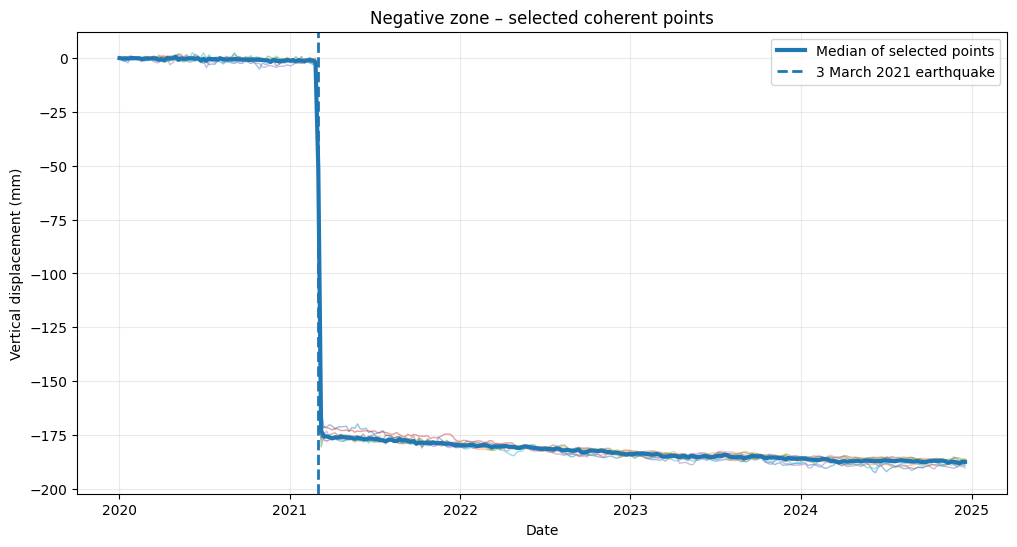

In [33]:
plot_selected_timeseries(
    neg_rank,
    aoi_vertical,
    "Negative zone – selected coherent points"
)

In [34]:
stable_2d = motion_qc[
    motion_qc["mean_velocity_vertical"].between(-1, 1) &
    motion_qc["mean_velocity_eastwest"].between(-1, 1)
].copy()

stable_2d = spatial_clusters(stable_2d)

print(
    stable_2d[stable_2d["spatial_cluster"] != -1]
    ["spatial_cluster"]
    .value_counts()
    .head(10)
)

spatial_cluster
2    8
3    8
0    6
1    6
4    6
Name: count, dtype: int64


In [35]:
stable_valid = stable_2d[
    stable_2d["spatial_cluster"] != -1
]

stable_id = (
    stable_valid["spatial_cluster"]
    .value_counts()
    .idxmax()
)

stable_zone = stable_valid[
    stable_valid["spatial_cluster"] == stable_id
].copy()

print("Stable zone points:", len(stable_zone))

Stable zone points: 8


In [36]:
def rank_stable(zone_df, source, n=10):

    d = source[source["pid"].isin(zone_df["pid"])].copy()
    d = d.set_index("pid")

    ts = d[date_cols].apply(pd.to_numeric, errors="coerce")

    ts = ts.apply(
        lambda r: r - r.dropna().iloc[0]
        if r.notna().any() else r,
        axis=1
    )

    median_ts = ts.median(axis=0)

    rows = []

    for pid in ts.index:

        s = ts.loc[pid]

        residual_rms = np.sqrt(
            np.nanmean((s - median_ts)**2)
        )

        rmse = zone_df.loc[
            zone_df["pid"] == pid,
            "rmse_ts_vertical"
        ].iloc[0]

        rows.append({
            "pid": pid,
            "residual_rms": residual_rms,
            "rmse_vertical": rmse
        })

    result = pd.DataFrame(rows)

    result["score"] = (
        result["residual_rms"]
        + 0.2 * result["rmse_vertical"]
    )

    return result.sort_values("score").head(n)

In [37]:
stable_rank = rank_stable(
    stable_zone,
    aoi_vertical,
    n=10
)

display(stable_rank)

,pid,residual_rms,rmse_vertical,score
2,10NgpILmo8,1.315414,1.5,1.615414
3,10NgpILmo9,1.734521,1.8,2.094521
4,10Ngtz120C,1.994799,2.2,2.434799
5,10Ngtz120D,2.821935,3.5,3.521935
7,10NgyfgHCI,4.439976,2.3,4.899976
0,10NgkbgXc5,4.899692,2.3,5.359692
6,10NgyfgHCF,4.722226,3.8,5.482226
1,10NgpILmo7,6.161505,1.2,6.401505


In [38]:
final_negative = neg_rank.head(10)["pid"].tolist()
final_positive = pos_rank.head(10)["pid"].tolist()
final_stable   = stable_rank.head(4)["pid"].tolist()

print("Negative:", final_negative)
print("Positive:", final_positive)
print("Stable:", final_stable)

Negative: ['10NRKDyXxY', '10NXymW754', '10NRKDyXy0', '10NROudn9y', '10NROudn9x', '10NWv9CgMS', '10NXIaWuKh', '10NWqSXRAP', '10NRAqe3ZH', '10NSbvHiHJ']
Positive: ['10NbuZ6rDJ', '10NbpsRc1I', '10NbuZ6rDO', '10NcMh6KNX', '10NcRNlZZt', '10NcRNlZZb', '10Ngfv1ITD', '10Nc3wRLbd', '10NcI0R5Bn', '10NhQnfkPq']
Stable: ['10NgpILmo8', '10NgpILmo9', '10Ngtz120C', '10Ngtz120D']


In [39]:
selection = pd.DataFrame({
    "zone": (
        ["Negative"] * len(final_negative) +
        ["Positive"] * len(final_positive) +
        ["Stable"]   * len(final_stable)
    ),
    "pid": (
        final_negative +
        final_positive +
        final_stable
    )
})

selection.to_csv(
    "/content/drive/MyDrive/EGMS_Greece_Project/final_selected_points.csv",
    index=False
)

display(selection)

,zone,pid
0,Negative,10NRKDyXxY
1,Negative,10NXymW754
2,Negative,10NRKDyXy0
3,Negative,10NROudn9y
4,Negative,10NROudn9x
5,Negative,10NWv9CgMS
6,Negative,10NXIaWuKh
7,Negative,10NWqSXRAP
8,Negative,10NRAqe3ZH
9,Negative,10NSbvHiHJ


In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def selected_zone_ts(source, pids):

    d = source[source["pid"].isin(pids)].copy()
    d = d.set_index("pid")

    ts = d[date_cols].apply(pd.to_numeric, errors="coerce")

    # Normalize each point to its first valid observation
    ts = ts.apply(
        lambda r: r - r.dropna().iloc[0]
        if r.notna().any() else r,
        axis=1
    )

    return ts


neg_ts = selected_zone_ts(aoi_vertical, final_negative)
pos_ts = selected_zone_ts(aoi_vertical, final_positive)
stable_ts = selected_zone_ts(aoi_vertical, final_stable)

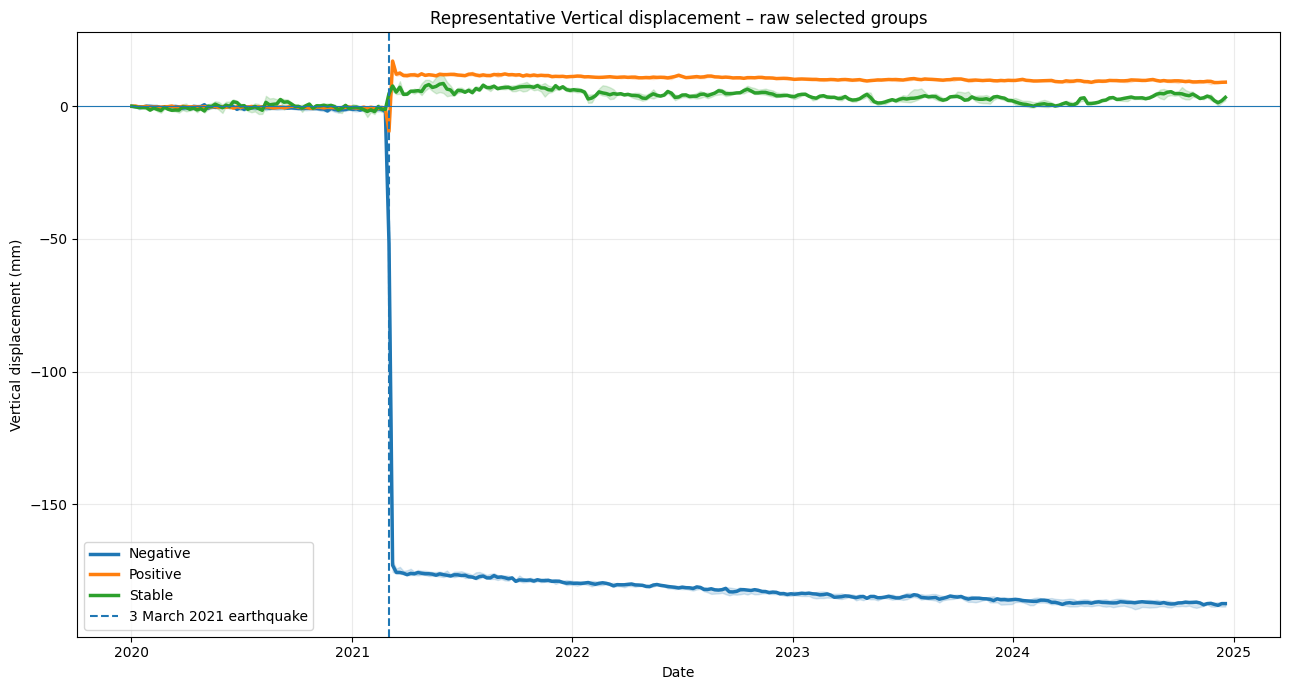

In [41]:
plt.figure(figsize=(13,7))

groups = {
    "Negative": neg_ts,
    "Positive": pos_ts,
    "Stable": stable_ts
}

for name, ts in groups.items():

    median = ts.median(axis=0)
    q25 = ts.quantile(0.25, axis=0)
    q75 = ts.quantile(0.75, axis=0)

    line, = plt.plot(
        dates,
        median,
        linewidth=2.5,
        label=name
    )

    plt.fill_between(
        dates,
        q25,
        q75,
        alpha=0.18,
        color=line.get_color()
    )

# March 2021 earthquake
plt.axvline(
    pd.Timestamp("2021-03-03"),
    linestyle="--",
    linewidth=1.5,
    label="3 March 2021 earthquake"
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Date")
plt.ylabel("Vertical displacement (mm)")
plt.title("Representative Vertical displacement – raw selected groups")

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()

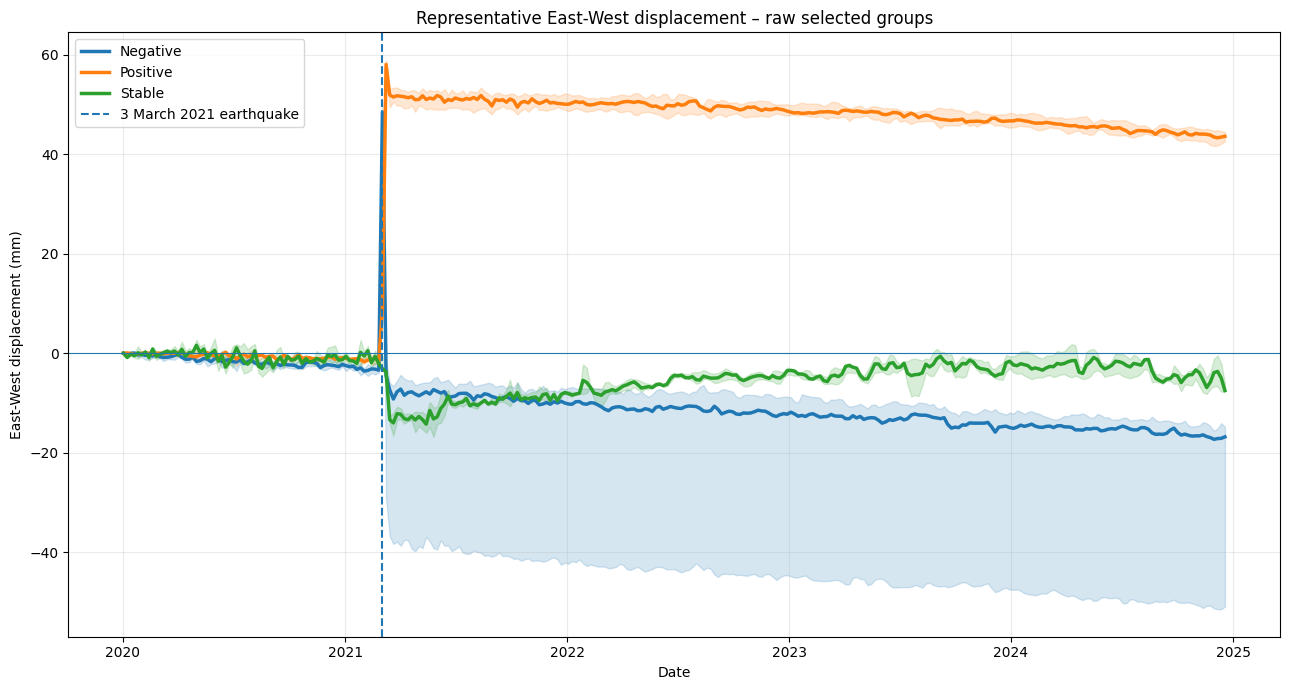

In [42]:
neg_ts_e = selected_zone_ts(aoi_eastwest, final_negative)
pos_ts_e = selected_zone_ts(aoi_eastwest, final_positive)
stable_ts_e = selected_zone_ts(aoi_eastwest, final_stable)

plt.figure(figsize=(13,7))

groups_e = {
    "Negative": neg_ts_e,
    "Positive": pos_ts_e,
    "Stable": stable_ts_e
}

for name, ts in groups_e.items():

    median = ts.median(axis=0)
    q25 = ts.quantile(0.25, axis=0)
    q75 = ts.quantile(0.75, axis=0)

    line, = plt.plot(
        dates,
        median,
        linewidth=2.5,
        label=name
    )

    plt.fill_between(
        dates,
        q25,
        q75,
        alpha=0.18,
        color=line.get_color()
    )

plt.axvline(
    pd.Timestamp("2021-03-03"),
    linestyle="--",
    linewidth=1.5,
    label="3 March 2021 earthquake"
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Date")
plt.ylabel("East-West displacement (mm)")
plt.title("Representative East-West displacement – raw selected groups")

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()

In [43]:
def summarize_group(ts, component):

    median = ts.median(axis=0)

    # 1. Earthquake step
    step = median[after_col] - median[before_col]

    # Convert column names to dates
    d = pd.to_datetime(median.index, format="%Y%m%d")
    y = median.values.astype(float)

    # 2. Post-event trend: April 2021 onward
    mask = d >= pd.Timestamp("2021-04-01")

    d_post = d[mask]
    y_post = y[mask]

    valid = np.isfinite(y_post)

    # elapsed years
    t = (
        (d_post[valid] - d_post[valid][0]).days
        / 365.25
    )

    slope = np.polyfit(
        t,
        y_post[valid],
        1
    )[0]

    # 3. Final displacement
    final_disp = median.dropna().iloc[-1]

    return {
        "Component": component,
        "Earthquake step (mm)": step,
        "Post-event trend (mm/yr)": slope,
        "Final displacement (mm)": final_disp
    }

In [44]:
summary = []

for zone, ts_v, ts_e in [
    ("Negative", neg_ts, neg_ts_e),
    ("Positive", pos_ts, pos_ts_e),
    ("Reference", stable_ts, stable_ts_e)
]:

    v = summarize_group(ts_v, "Vertical")
    e = summarize_group(ts_e, "East-West")

    v["Zone"] = zone
    e["Zone"] = zone

    summary.extend([v, e])

summary_df = pd.DataFrame(summary)

summary_df = summary_df[
    [
        "Zone",
        "Component",
        "Earthquake step (mm)",
        "Post-event trend (mm/yr)",
        "Final displacement (mm)"
    ]
]

summary_df = summary_df.round(2)

display(summary_df)

,Zone,Component,Earthquake step (mm),Post-event trend (mm/yr),Final displacement (mm)
0,Negative,Vertical,-171.00,-3.23,-187.45
1,Negative,East-West,-1.05,-2.30,-16.80
2,Positive,Vertical,17.90,-0.75,9.10
3,Positive,East-West,59.65,-2.06,43.60
4,Reference,Vertical,8.80,-1.26,3.35
5,Reference,East-West,-1.65,2.27,-7.50


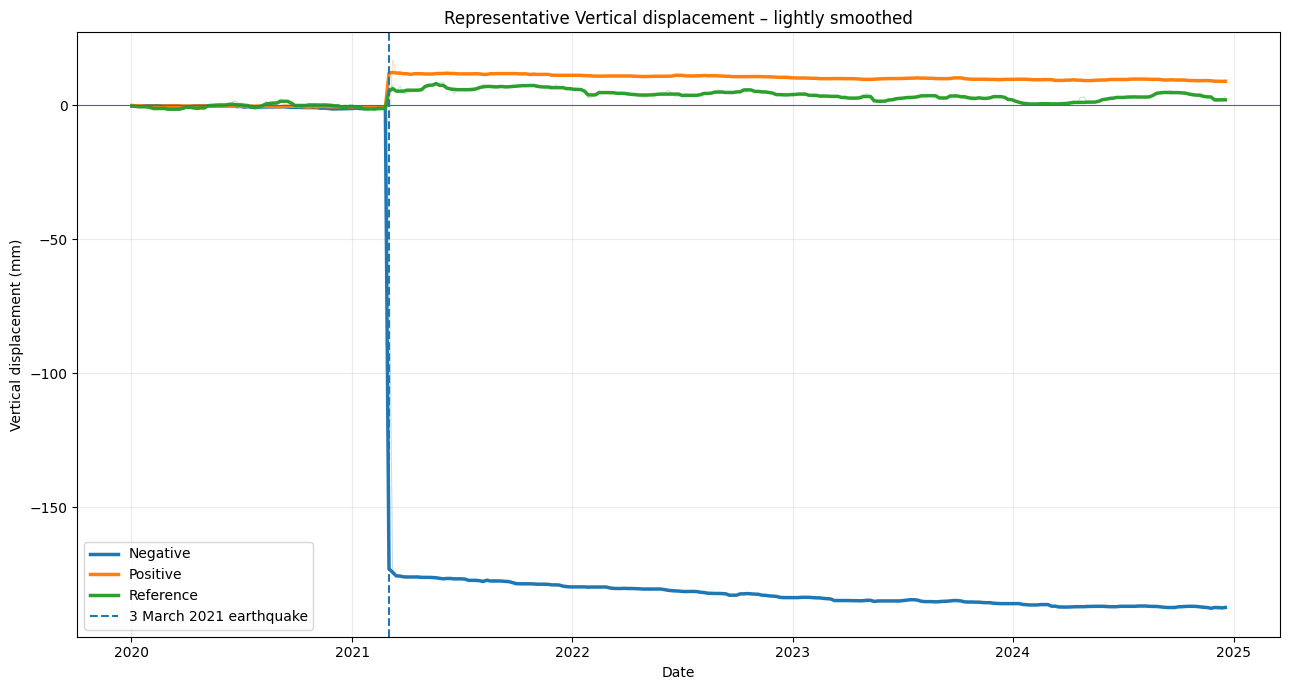

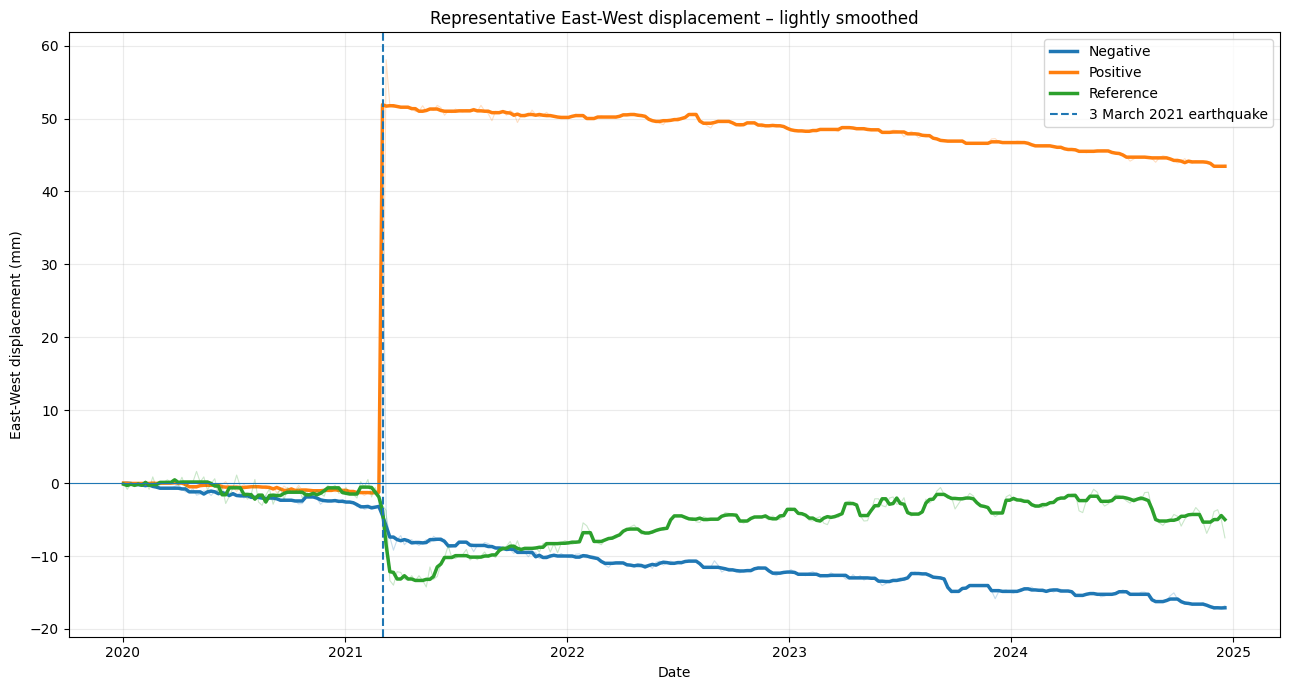

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

event_date = pd.Timestamp("2021-03-03")

def raw_and_smoothed(ts, window=5):

    # Median of selected neighbouring points
    raw = ts.median(axis=0)

    raw.index = pd.to_datetime(
        raw.index,
        format="%Y%m%d"
    )

    # Split around earthquake so smoothing does not smear the jump
    pre = raw[raw.index < event_date]
    post = raw[raw.index >= event_date]

    pre_smooth = pre.rolling(
        window=window,
        center=True,
        min_periods=1
    ).median()

    post_smooth = post.rolling(
        window=window,
        center=True,
        min_periods=1
    ).median()

    smooth = pd.concat([pre_smooth, post_smooth])

    return raw, smooth


# --------------------------------
# VERTICAL
# --------------------------------

plt.figure(figsize=(13,7))

for name, ts in {
    "Negative": neg_ts,
    "Positive": pos_ts,
    "Reference": stable_ts
}.items():

    raw, smooth = raw_and_smoothed(ts)

    line, = plt.plot(
        smooth.index,
        smooth.values,
        linewidth=2.5,
        label=name
    )

    plt.plot(
        raw.index,
        raw.values,
        linewidth=0.8,
        alpha=0.25,
        color=line.get_color()
    )

plt.axvline(
    event_date,
    linestyle="--",
    linewidth=1.5,
    label="3 March 2021 earthquake"
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Date")
plt.ylabel("Vertical displacement (mm)")
plt.title("Representative Vertical displacement – lightly smoothed")

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------
# EAST-WEST
# --------------------------------

plt.figure(figsize=(13,7))

for name, ts in {
    "Negative": neg_ts_e,
    "Positive": pos_ts_e,
    "Reference": stable_ts_e
}.items():

    raw, smooth = raw_and_smoothed(ts)

    line, = plt.plot(
        smooth.index,
        smooth.values,
        linewidth=2.5,
        label=name
    )

    plt.plot(
        raw.index,
        raw.values,
        linewidth=0.8,
        alpha=0.25,
        color=line.get_color()
    )

plt.axvline(
    event_date,
    linestyle="--",
    linewidth=1.5,
    label="3 March 2021 earthquake"
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Date")
plt.ylabel("East-West displacement (mm)")
plt.title("Representative East-West displacement – lightly smoothed")

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()